,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
513,700,2016,NonResidential,Supermarket / Grocery Store,IUC- Whole Foods Interbay,98119.0,7666201460,7,MAGNOLIA / QUEEN ANNE,47.63718,...,12843856.0,0.0,0.0,0.0,0.0,0.0,False,Compliant,0.0,0.0


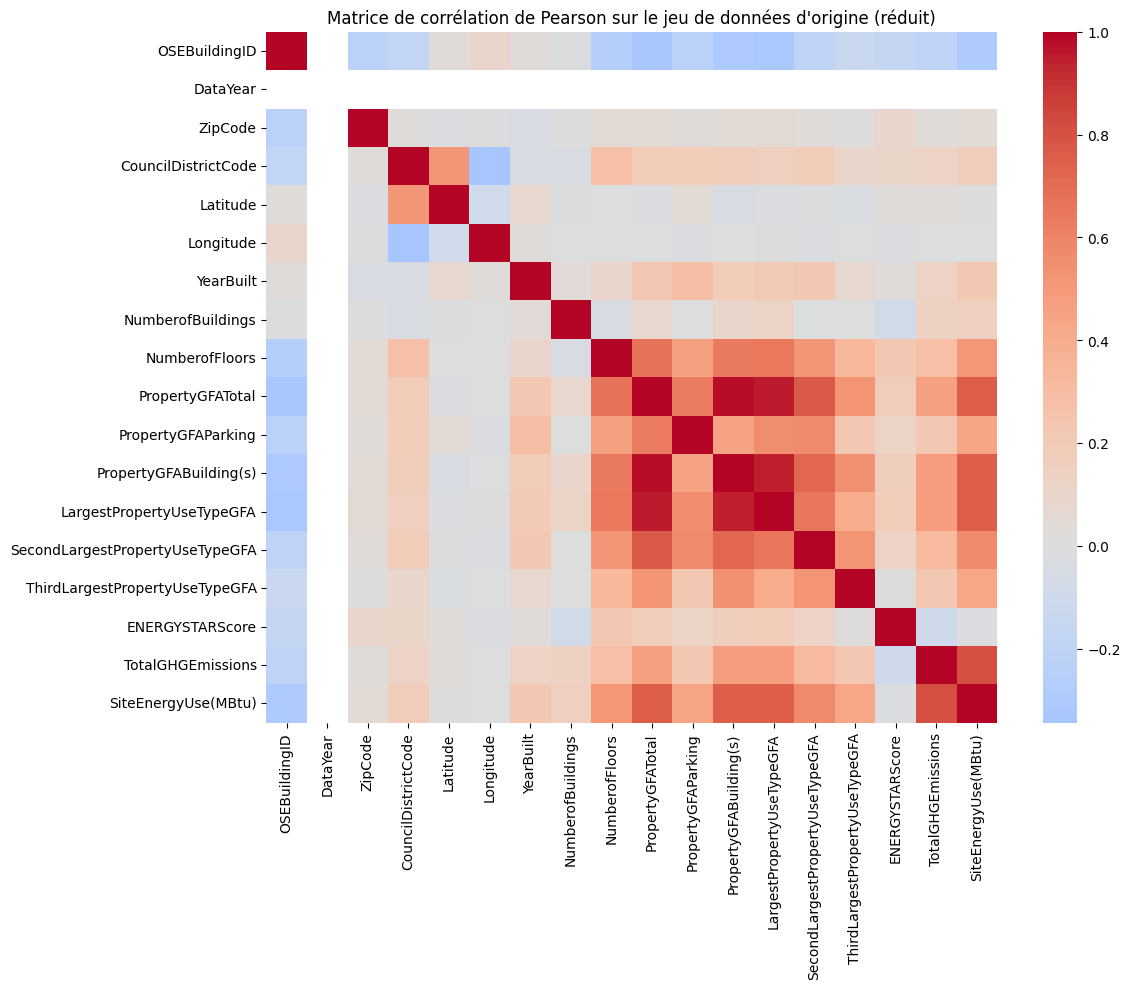

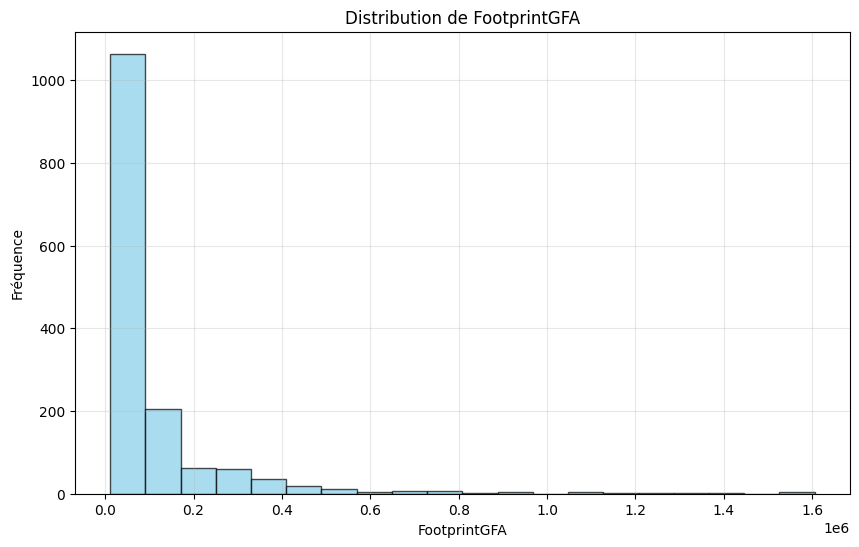

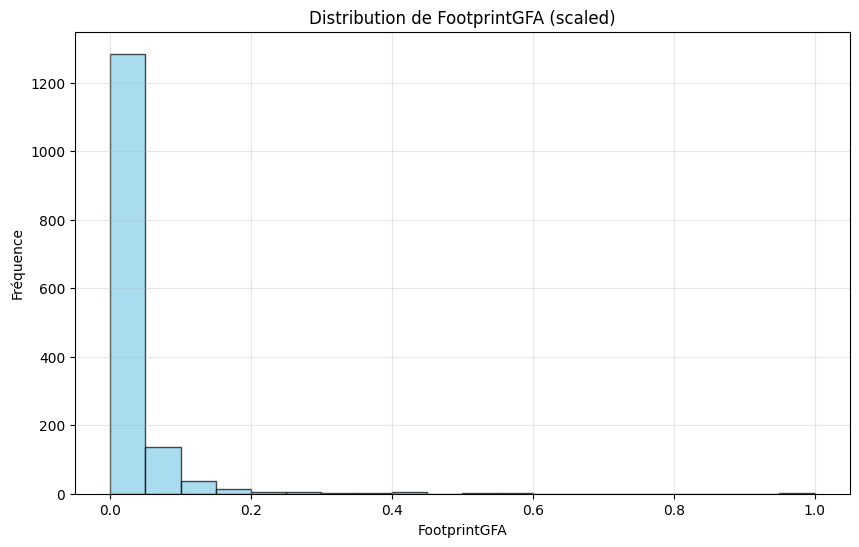

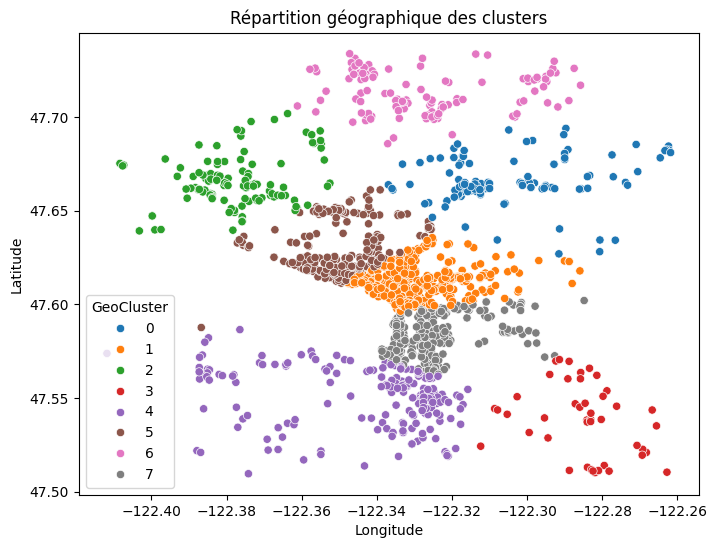

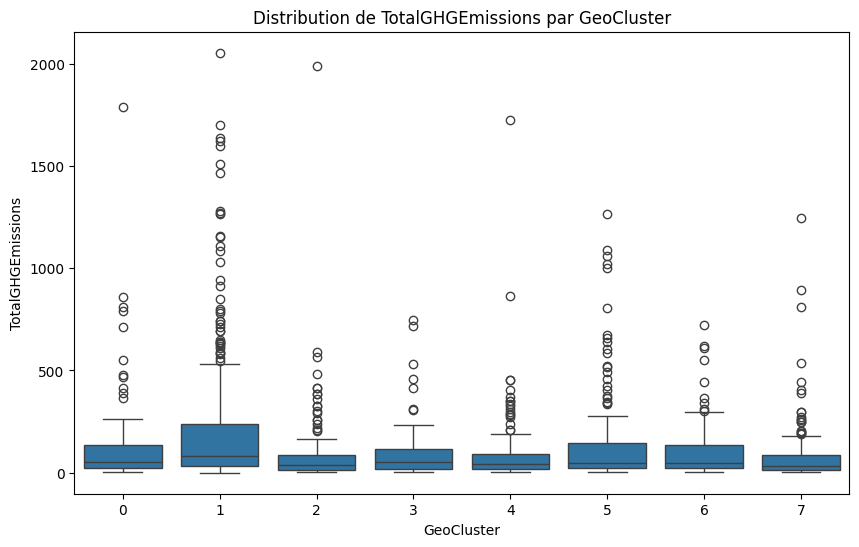

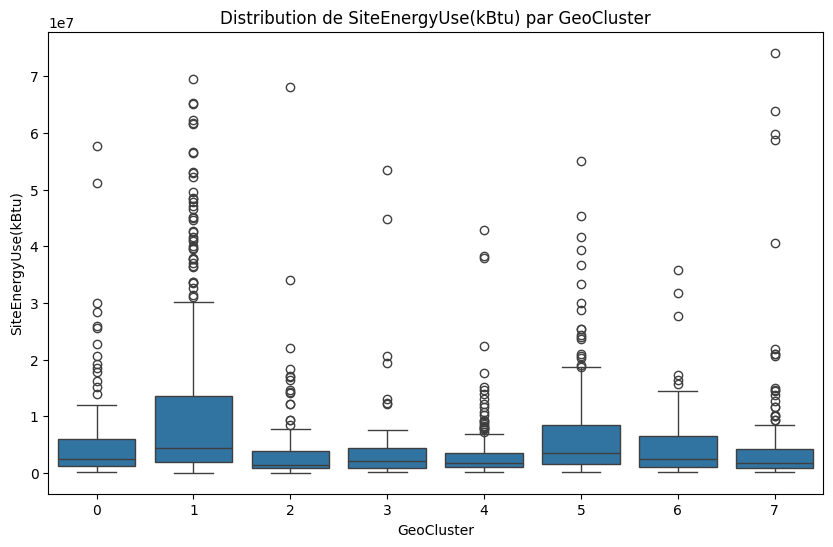

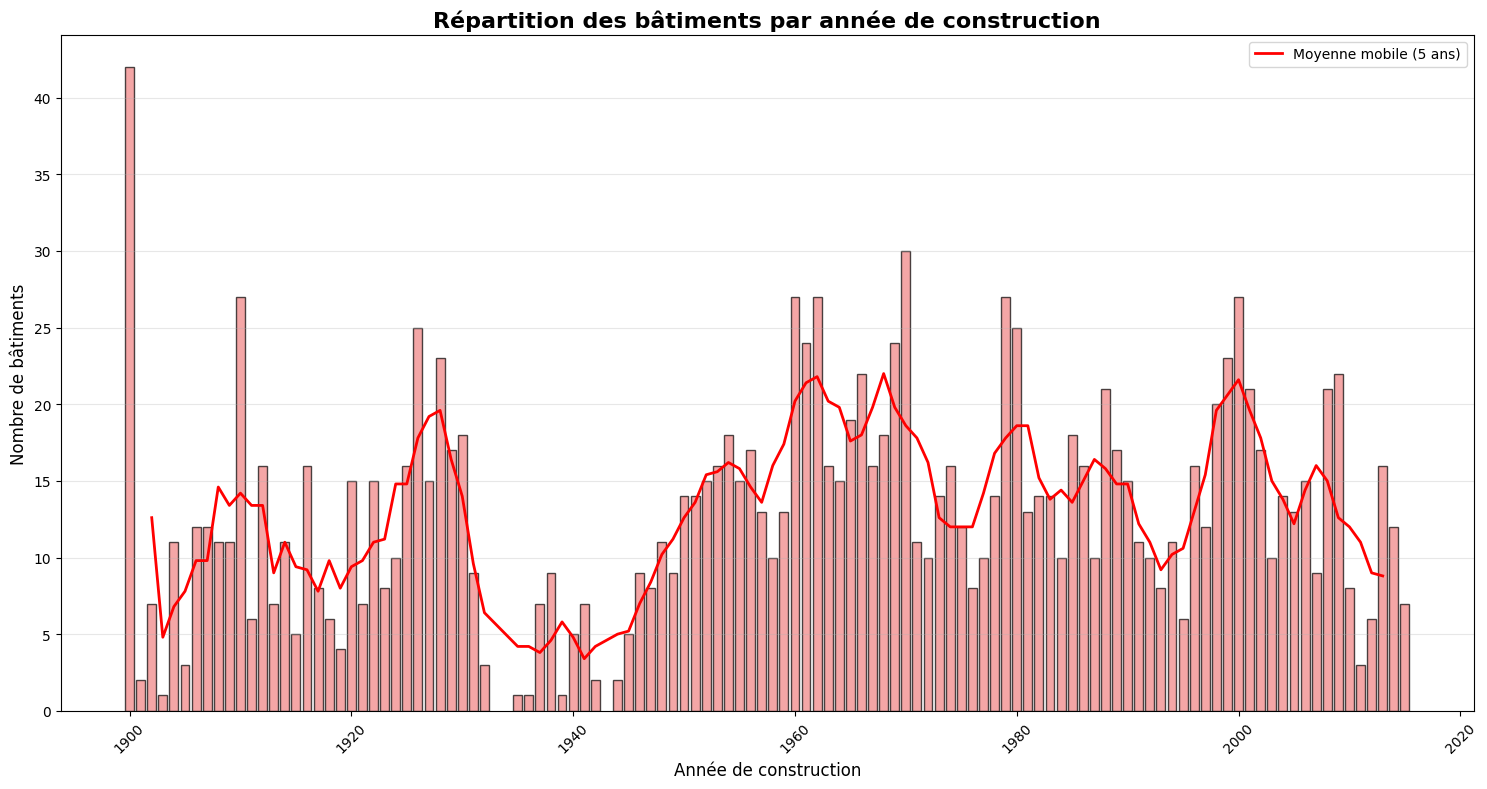

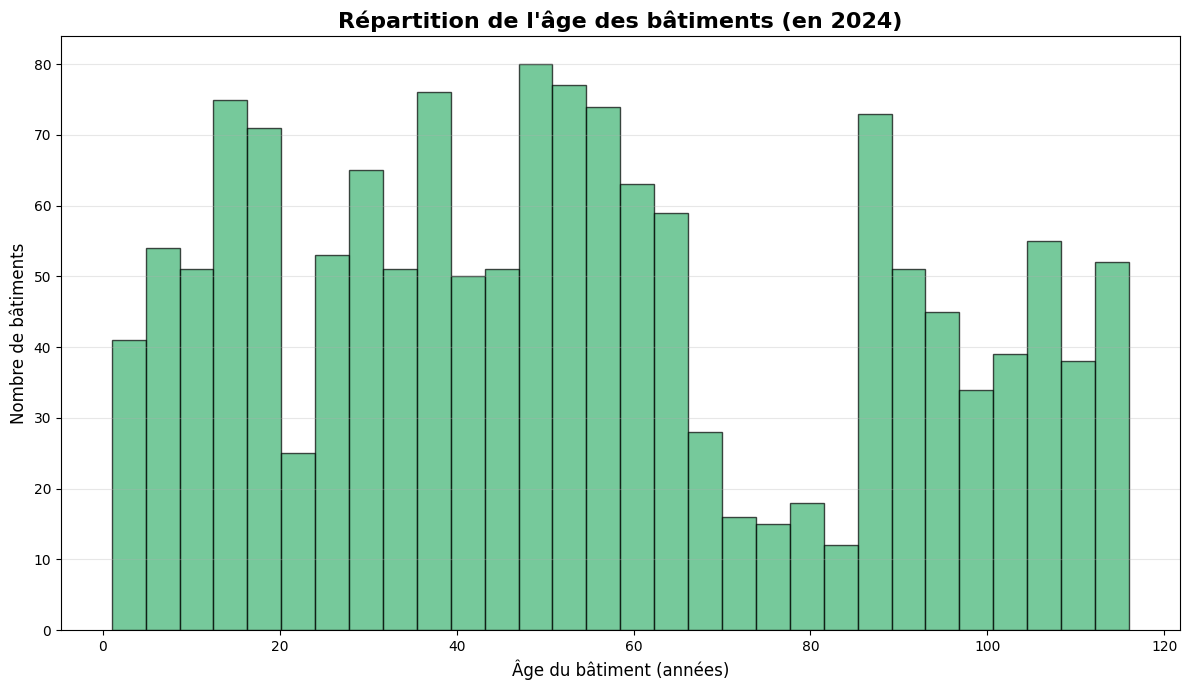

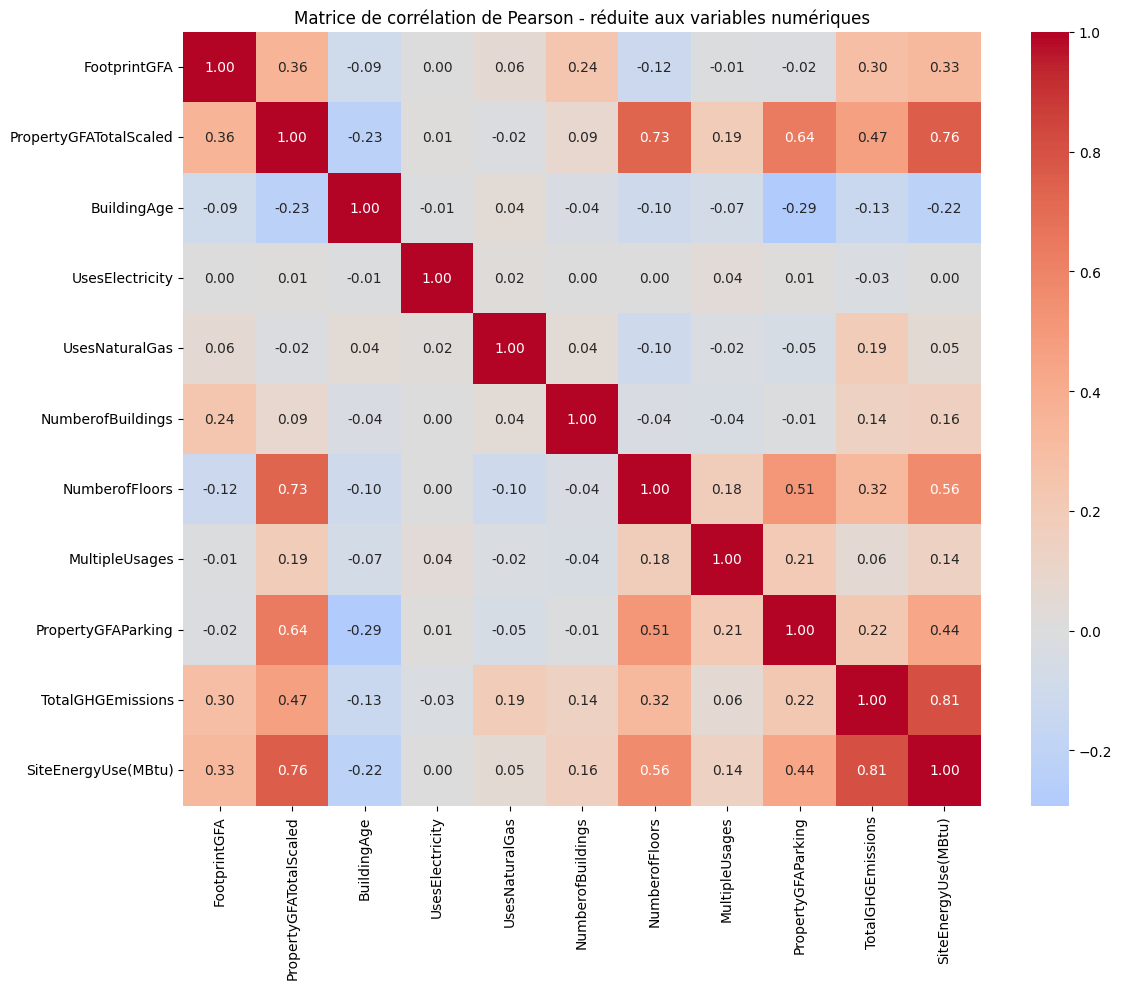

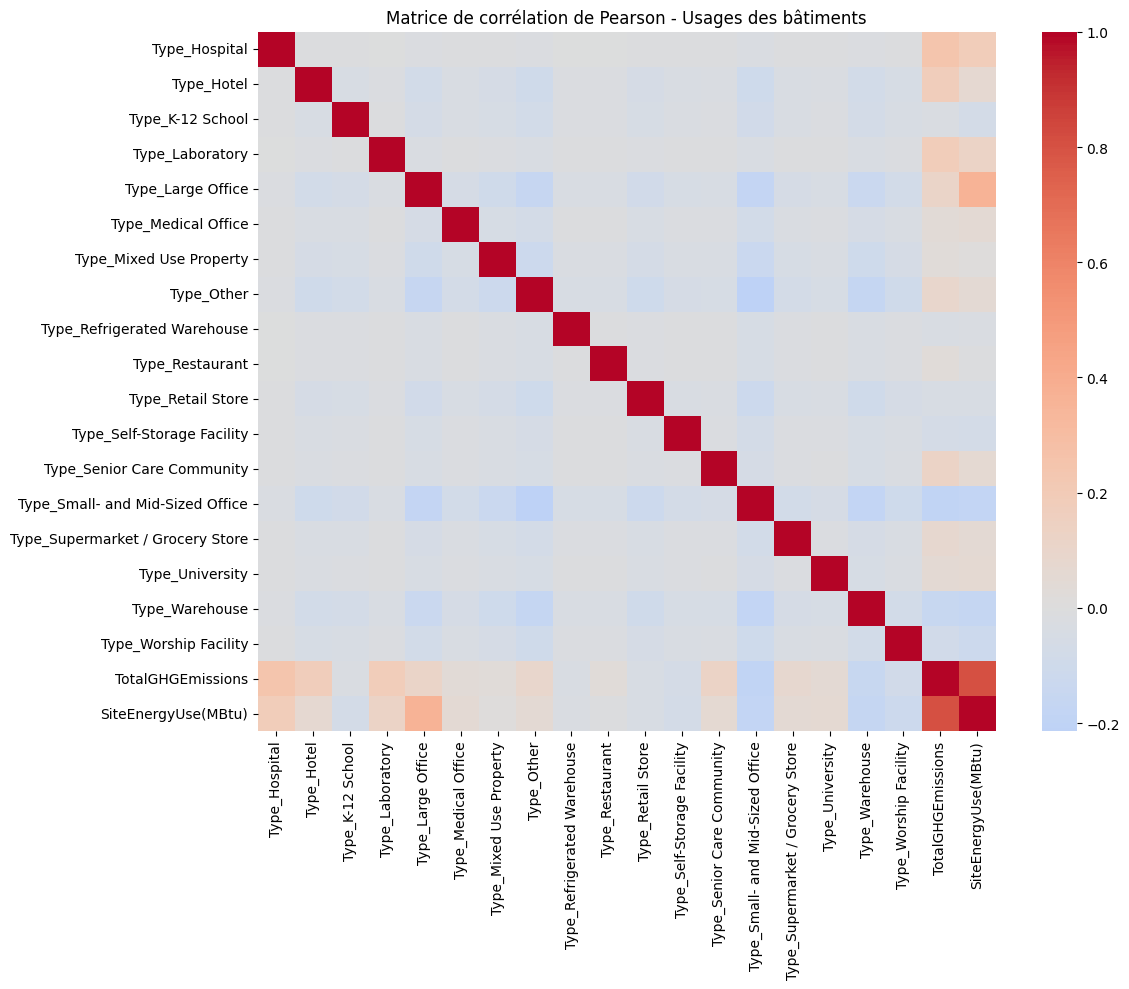

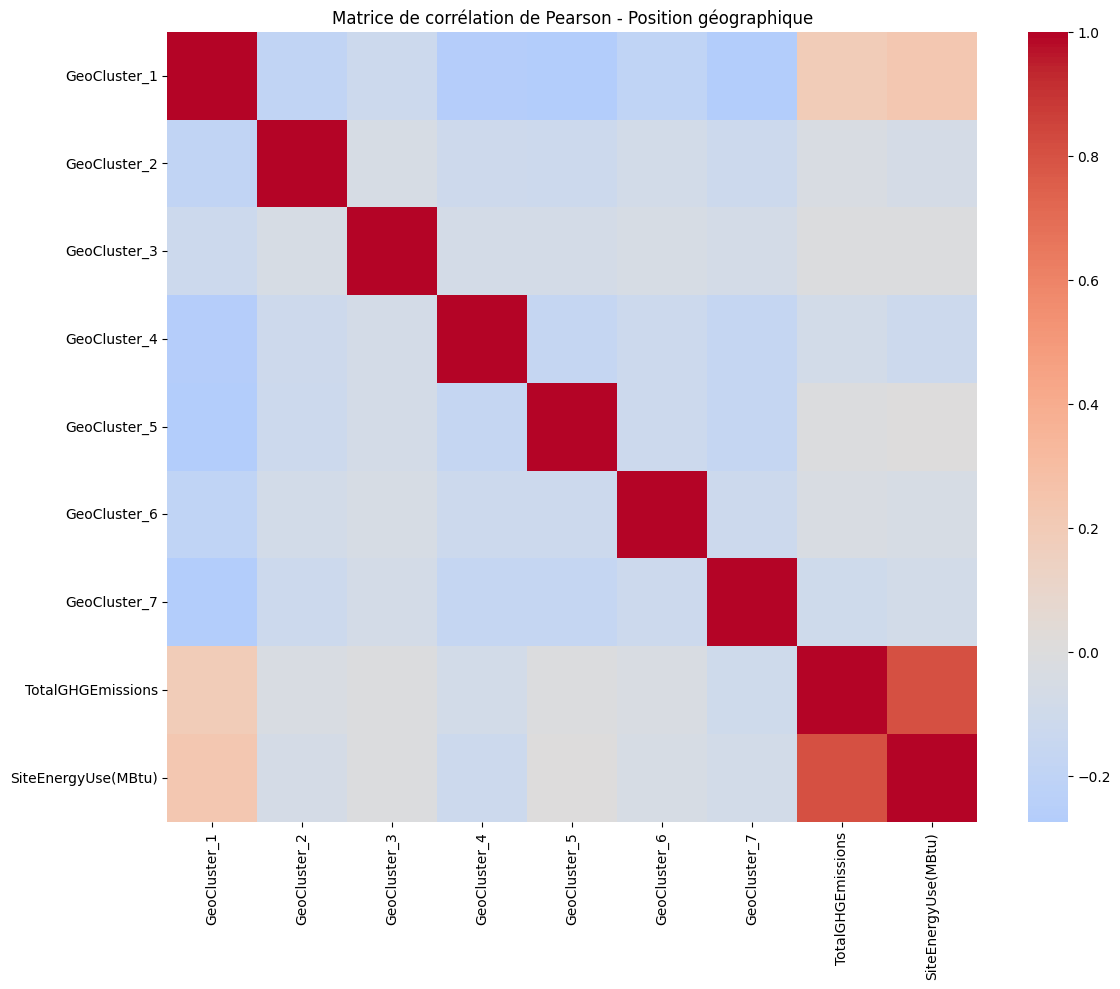

In [1]:
# On exécute le précédent notebook car on est dépendant des résultats
import sys
import os
from contextlib import redirect_stdout, redirect_stderr

# Désactiver l'affichage AVANT d'importer matplotlib
%matplotlib agg

with open(os.devnull, 'w') as fnull:
    with redirect_stdout(fnull), redirect_stderr(fnull):
        %run 2+3_feature-engineering.ipynb

# FORCER la réactivation de l'affichage
%matplotlib inline

# Réinitialiser matplotlib pour forcer le nouveau backend
import matplotlib
matplotlib.pyplot.close('all')  # Fermer toutes les figures existantes

# Modèles pour prédire la consommation en énergie
## Régression linéaire

MSE: 39721252.05247761
RMSE: 6302.479833563739
MAE: 3388.824354532288
MAPE: 1.5298352165191655
R²: 0.701011458557852
              réel        prédit
1698    313.528094   -136.899831
1568    222.255906   2682.454549
2901   3605.749750   5785.439531
1875   1602.084375   3427.029455
1753  14524.386000   6314.961499
657    1618.916375    516.598915
556   17750.994000  17580.514250
366   17225.444000   6708.843235
406    3181.045500   4166.004444
305    4169.431500   7597.949247
1939   1280.263750    797.318080
1125  10234.721000   6125.354451
2182    229.856406   2132.268493
3028   2076.289625   3064.037973
80     5448.975000   6077.740226
333   11594.121000  24600.276889
1292   1832.808750   6191.283821
425    1847.401000   2189.235970
2414   3168.131000   4818.168244
60    16402.563000  10164.047211


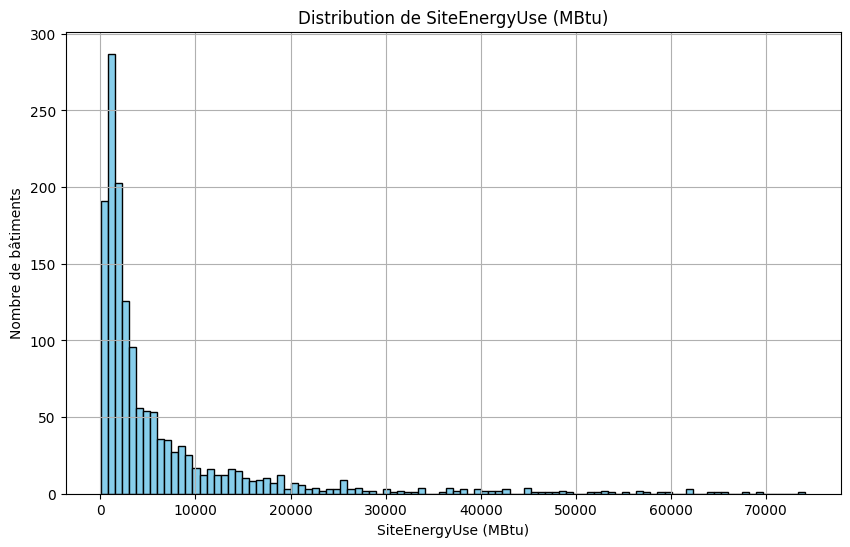

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error

# on fixe un random_state pour la reproductibilité des résultats
random_state = 42

# les variables prédictives
X = df_selected

# Première variable cible : énergie totale utilisée
y = df['SiteEnergyUse(MBtu)']

# on choisit un modèle de régression linéaire
reg = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=random_state)

reg.fit(X_train, y_train)
y_pred_test = reg.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred_test)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test))}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test)}")
print(f"R²: {r2_score(y_test, y_pred_test)}")

comparaison = pd.DataFrame({'réel': y_test, 'prédit': y_pred_test})
print(comparaison.head(20))

plt.figure(figsize=(10,6))
plt.hist(df['SiteEnergyUse(MBtu)'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel('SiteEnergyUse (MBtu)')
plt.ylabel('Nombre de bâtiments')
plt.title('Distribution de SiteEnergyUse (MBtu)')
plt.grid(True)
plt.show()

### Validation croisée

On réeffectue la régression linéaire avec une validation croisée cross_validate.

On crée une fonction qui permet de faire une validation croisée et afficher les résultats pour tous nos autres modèles

In [3]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression

# Fonction pour la validation croisée de modèles et affichage des résultats
def cross_validate_and_print_results(reg, X, y):
    cv_results = cross_validate(
        reg, 
        X, 
        y, 
        cv=5,  # nombre de folds (par défaut 5)
        scoring=['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
        return_train_score=False
    )

    # Calcul des métriques
    mse_mean = -cv_results['test_neg_mean_squared_error'].mean()
    rmse_mean = np.sqrt(mse_mean)
    mae_mean = -cv_results['test_neg_mean_absolute_error'].mean()
    mape_mean = -cv_results['test_neg_mean_absolute_percentage_error'].mean()
    r2_mean = cv_results['test_r2'].mean()
    
    # Création du tableau
    results_df = pd.DataFrame({
        'Métrique': ['MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R²'],
        'Moyenne': [
            f"{mse_mean:,.0f}",
            f"{rmse_mean:,.1f}",
            f"{mae_mean:,.1f}",
            f"{mape_mean*100:.2f}",
            f"{r2_mean:.4f}"
        ]
    })

    styled_table = (
        results_df.style
        .set_caption("Résultats Validation Croisée")
        .hide(axis="index")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles(
            [
                {"selector": "th", "props": [("text-align", "left")]},
                {"selector": "td", "props": [("min-width", "200px")]}
            ]
        )
    )

    display(styled_table)
# Modèle
reg = LinearRegression()

# Validation croisée
cross_validate_and_print_results(reg, X, y)


Métrique,Moyenne
MSE,"38,932,882"
RMSE,"6,239.6"
MAE,"3,297.6"
MAPE (%),141.21
R²,0.4639


**Remarque : on constate avec la validation croisée que le modèle semble moins performant que notre premier essai** (ce qui est normal car la validation croisée permet de réduire l'overfit)

* RMSE et MAE moyens **proches** du premier essai
* MAPE moyen **plus élevé**
* **R² beaucoup plus bas** : de ~0,7 on passe à ~0.47

### Bilan

**On constate que la régression linéaire n'est pas adaptée pour prédire la consommation en énergie. On constate également que la distribution de cette variable sur les données statistiques existantes n'est pas linéaire. Ces résultats sont cohérents car la régression linéaire n'est pas adaptée pour prédire une variable dont la distribution est non-linéaire**

## RandomForestRegressor

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

reg = RandomForestRegressor(n_estimators=100, random_state=random_state)

cross_validate_and_print_results(reg, X, y)

Métrique,Moyenne
MSE,"37,697,764"
RMSE,"6,139.9"
MAE,"3,128.7"
MAPE (%),98.34
R²,0.5269


**Remarque : on constate un R² un peu meilleur, ainsi qu'une MAE et RMSE un peu meilleures également. Toutefois l'amélioration est faible avec ce modèle, il est difficile de conclure que ce modèle est meilleur**

## XGBoost (Extreme Gradient Boosting)

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

reg = GradientBoostingRegressor(n_estimators=100, random_state=random_state)

cross_validate_and_print_results(reg, X, y)

Métrique,Moyenne
MSE,"34,869,270"
RMSE,"5,905.0"
MAE,"3,064.8"
MAPE (%),100.39
R²,0.5487


**Remarque : on constate un R² sensiblement meilleur, ainsi qu'une MAE et RMSE un peu meilleures**

# Modèles pour prédire les émissions de gaz à effet de serre

On va appliquer directement la validation croisée à nos modèles

## Régression linéaire

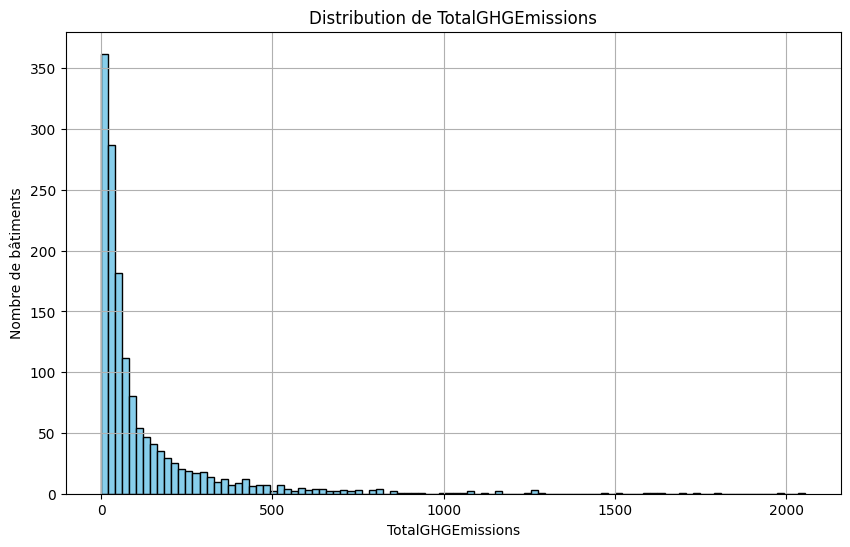

Métrique,Moyenne
MSE,"28,251"
RMSE,168.1
MAE,83.9
MAPE (%),194.57
R²,0.3446


In [6]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression

X = df_selected
y = df['TotalGHGEmissions']

plt.figure(figsize=(10,6))
plt.hist(df['TotalGHGEmissions'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel('TotalGHGEmissions')
plt.ylabel('Nombre de bâtiments')
plt.title('Distribution de TotalGHGEmissions')
plt.grid(True)
plt.show()

cross_validate_and_print_results(reg, X, y)

### Bilan

On constate que la **régression linéaire** n'est pas adaptée en l'état pour prédire les émissions de gaz à effet de serre.
On constate également que la distribution de cette variable sur les données statistiques existantes n'est **pas linéaire**.
La conclusion est la même que pour la précédente avec la consommation en énergie

## RandomForestRegressor

In [7]:
reg = RandomForestRegressor(n_estimators=100, random_state=random_state)
cross_validate_and_print_results(reg, X, y)

Métrique,Moyenne
MSE,"29,422"
RMSE,171.5
MAE,84.9
MAPE (%),174.08
R²,0.3286


## XGBoost (Extreme Gradient Boosting)

In [8]:
reg = GradientBoostingRegressor(n_estimators=100, random_state=random_state)
cross_validate_and_print_results(reg, X, y)

Métrique,Moyenne
MSE,"28,251"
RMSE,168.1
MAE,83.9
MAPE (%),194.57
R²,0.3446


# Optimisation du XGBoost

On a constaté que le meilleur modèle dans notre cas est le XGBoost.
On va maintenant chercher à optimiser son utilisation afin d'améliorer les prédictions

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

# X = df_selected
# y = df['SiteEnergyUse(kBtu)']
# groups = df['OSEBuildingID'] if disponible, sinon None
y_log = np.log1p(y)

def mae_exp(y_true_log, y_pred_log):
    return mean_absolute_error(np.expm1(y_true_log), np.expm1(y_pred_log))

scorers = {
    'r2_log': make_scorer(r2_score),
    'mae_log': make_scorer(mean_absolute_error, greater_is_better=False),
    'mae_linear': make_scorer(mae_exp, greater_is_better=False)
}

gb = GradientBoostingRegressor(random_state=42)
param_distrib = {
    'n_estimators': [200, 400, 600, 800],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [1, 5, 10, 20],
    'subsample': [0.7, 0.85, 1.0]
}

cv = GroupKFold(n_splits=5) if 'groups' in locals() and groups is not None else 5

search = RandomizedSearchCV(
    gb,
    param_distributions=param_distrib,
    n_iter=30,
    scoring='neg_mean_absolute_error',  # sur y_log
    cv=cv,
    random_state=42,
    n_jobs=-1
)
search.fit(X, y_log, groups=groups if 'groups' in locals() and groups is not None else None)
best = search.best_estimator_

cv_res = cross_validate(
    best, X, y_log, cv=cv, scoring=scorers,
    groups=groups if 'groups' in locals() and groups is not None else None,
    return_train_score=False
)

print("Best params:", search.best_params_)
print("MAE_log (↓):", -cv_res['test_mae_log'].mean())
print("MAE_linear (↓, retransformé):", -cv_res['test_mae_linear'].mean())
print("R2_log (↑):", cv_res['test_r2_log'].mean())